# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ameen740/Internship_Flyrank/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

## Research Question

Can observed search-performance signals from an earlier period be used to prioritize content items for a potential refresh or content review?

## Decision Supported

This analysis supports the decision of which content items should be reviewed first for a possible refresh.

The goal is to create a transparent and repeatable prioritization method using observed search-performance signals. The analysis does not claim that refreshing a page will cause better search performance.

In [37]:
research_question = (
    "Can observed search-performance signals from an earlier period "
    "be used to prioritize content items for a potential refresh "
    "or content review?"
)

decision_supported = (
    "Prioritize content items for human review for a possible refresh."
)

print("Research question:")
print(research_question)

print("\nDecision supported:")
print(decision_supported)

Research question:
Can observed search-performance signals from an earlier period be used to prioritize content items for a potential refresh or content review?

Decision supported:
Prioritize content items for human review for a possible refresh.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

This analysis uses the FlyRank ML Internship dataset and the `fact_content_daily_performance` table.

The analysis uses the March 2026 reporting window from March 1 through March 31, 2026.

The first part of the month, March 1–21, is used to create historical search-performance features. The later period, March 22–31, is used as the future outcome window.

The main fields used are Google Search Console impressions, clicks, and summed position.

Client and content identifiers are used internally to aggregate observations but are excluded from model features and public outputs.

Private client names, URLs, search queries, credentials, and other identifying information are not included in the public research paper.

In [ ]:
# Check what variables are currently available
%whos

Variable             Type    Data/Info
--------------------------------------
decision_supported   str     Prioritize content items <...>w for a possible refresh.
research_question    str     Can observed search-perfo<...>tent refresh opportunity?


In [38]:
print("Data shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nDate range:")
print(df["report_date"].min(), "to", df["report_date"].max())

print("\nMissing values:")
print(df.isna().sum())

assert len(df) > 0
assert df["report_date"].min().strftime("%Y-%m-%d") == "2026-03-01"
assert df["report_date"].max().strftime("%Y-%m-%d") == "2026-03-31"

print("\nQ2 checks passed.")

Data shape: (9841378, 7)

Columns:
['report_date', 'client_hash_id', 'content_hash_id', 'gsc_impressions', 'gsc_clicks', 'gsc_sum_position', 'gsc_data_available']

Date range:
2026-03-01 00:00:00 to 2026-03-31 00:00:00

Missing values:
report_date           0
client_hash_id        0
content_hash_id       0
gsc_impressions       0
gsc_clicks            0
gsc_sum_position      0
gsc_data_available    0
dtype: int64

Q2 checks passed.


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

The methodology separates historical features from the future outcome to reduce leakage.

## Unit of Analysis

The analysis uses one row per client and content item after aggregating daily search-performance data within the defined time windows.

## Feature Window

March 1–21, 2026 is used as the historical feature window.

The features are:

- total GSC impressions
- total GSC clicks
- historical CTR
- average GSC position

## Outcome Window

March 22–31, 2026 is used as the future outcome window.

A content item is treated as a future refresh opportunity when it has meaningful search visibility in the outcome window and a low future CTR.

The outcome rule is:

- future impressions >= 100
- future CTR < 2%

Items meeting both conditions are labeled `REFRESH_OPPORTUNITY`. Other items are labeled `NO_ACTION`.

## Baseline

The baseline uses the historical feature window only.

A content item is considered a baseline candidate when:

- historical impressions >= 100
- historical CTR < 2%

The baseline ranks candidates using:

`historical impressions / (historical CTR + 0.1)`

## Model

A Logistic Regression model uses only historical features from March 1–21.

The future outcome is never included as a model feature.

Client identifiers and content identifiers are excluded from model features.

## Validation

The model and baseline are evaluated against the same future outcome labels.

The evaluation measures how well each method identifies content that later meets the defined refresh-opportunity condition.

## Leakage Checks

No future-window impressions, clicks, CTR, position, future labels, client identifiers, or content identifiers are used as predictive features.

In [39]:
import numpy as np
import pandas as pd

# Make a clean copy
work_df = df.copy()

# Make sure the date column is datetime
work_df["report_date"] = pd.to_datetime(work_df["report_date"])

# Historical feature window
historical_df = work_df[
    (work_df["report_date"] >= "2026-03-01") &
    (work_df["report_date"] <= "2026-03-21")
].copy()

# Future outcome window
future_df = work_df[
    (work_df["report_date"] >= "2026-03-22") &
    (work_df["report_date"] <= "2026-03-31")
].copy()

print("Historical rows:", len(historical_df))
print("Future rows:", len(future_df))

Historical rows: 6573997
Future rows: 3267381


In [40]:
historical_content = (
    historical_df
    .groupby(["client_hash_id", "content_hash_id"], as_index=False)
    .agg(
        historical_impressions=("gsc_impressions", "sum"),
        historical_clicks=("gsc_clicks", "sum"),
        historical_sum_position=("gsc_sum_position", "sum")
    )
)

historical_content["historical_ctr_pct"] = np.where(
    historical_content["historical_impressions"] > 0,
    (
        historical_content["historical_clicks"]
        / historical_content["historical_impressions"]
    ) * 100,
    0
)

historical_content["historical_avg_position"] = np.where(
    historical_content["historical_impressions"] > 0,
    (
        historical_content["historical_sum_position"]
        / historical_content["historical_impressions"]
    ),
    np.nan
)

print("Historical content rows:", len(historical_content))

Historical content rows: 324297


In [41]:
future_content = (
    future_df
    .groupby(["client_hash_id", "content_hash_id"], as_index=False)
    .agg(
        future_impressions=("gsc_impressions", "sum"),
        future_clicks=("gsc_clicks", "sum"),
        future_sum_position=("gsc_sum_position", "sum")
    )
)

future_content["future_ctr_pct"] = np.where(
    future_content["future_impressions"] > 0,
    (
        future_content["future_clicks"]
        / future_content["future_impressions"]
    ) * 100,
    0
)

future_content["future_avg_position"] = np.where(
    future_content["future_impressions"] > 0,
    (
        future_content["future_sum_position"]
        / future_content["future_impressions"]
    ),
    np.nan
)

# Future refresh opportunity
future_content["outcome_label"] = np.where(
    (future_content["future_impressions"] >= 100) &
    (future_content["future_ctr_pct"] < 2.0),
    "REFRESH_OPPORTUNITY",
    "NO_ACTION"
)

print("Future outcome distribution:")
print(future_content["outcome_label"].value_counts())

Future outcome distribution:
outcome_label
NO_ACTION              257355
REFRESH_OPPORTUNITY     74081
Name: count, dtype: int64


In [42]:
model_df = historical_content.merge(
    future_content[
        [
            "client_hash_id",
            "content_hash_id",
            "future_impressions",
            "future_clicks",
            "future_ctr_pct",
            "future_avg_position",
            "outcome_label"
        ]
    ],
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

print("Model dataset shape:", model_df.shape)

print("\nOutcome distribution:")
print(model_df["outcome_label"].value_counts())

Model dataset shape: (324296, 12)

Outcome distribution:
outcome_label
NO_ACTION              250245
REFRESH_OPPORTUNITY     74051
Name: count, dtype: int64


In [43]:
model_df["baseline_candidate"] = (
    (model_df["historical_impressions"] >= 100) &
    (model_df["historical_ctr_pct"] < 2.0)
)

model_df["baseline_score"] = np.where(
    model_df["baseline_candidate"],
    model_df["historical_impressions"] /
    (model_df["historical_ctr_pct"] + 0.1),
    0
)

print("Baseline candidates:", model_df["baseline_candidate"].sum())

Baseline candidates: 87958


In [45]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

features = [
    "historical_impressions",
    "historical_clicks",
    "historical_ctr_pct",
    "historical_avg_position"
]

X = model_df[features].replace([np.inf, -np.inf], np.nan)
y = model_df["outcome_label"]

# Remove rows with missing model values
valid = X.notna().all(axis=1) & y.notna()

X = X.loc[valid]
y = y.loc[valid]
model_clean = model_df.loc[valid].copy()

print("Features:")
print(features)

print("\nModel shape:", X.shape)
print("\nOutcome distribution:")
print(y.value_counts())

Features:
['historical_impressions', 'historical_clicks', 'historical_ctr_pct', 'historical_avg_position']

Model shape: (162300, 4)

Outcome distribution:
outcome_label
NO_ACTION              89734
REFRESH_OPPORTUNITY    72566
Name: count, dtype: int64


In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

model.fit(X_train, y_train)

model_predictions = model.predict(X_test)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Model trained successfully.")

Training rows: 129840
Test rows: 32460
Model trained successfully.


In [47]:
future_columns = [
    "future_impressions",
    "future_clicks",
    "future_ctr_pct",
    "future_avg_position",
    "outcome_label"
]

print("Features used by model:")
print(features)

print("\nFuture columns excluded from model:")
print(future_columns)

assert not any(col in features for col in future_columns)
assert "client_hash_id" not in features
assert "content_hash_id" not in features

print("\nLeakage checks passed.")

Features used by model:
['historical_impressions', 'historical_clicks', 'historical_ctr_pct', 'historical_avg_position']

Future columns excluded from model:
['future_impressions', 'future_clicks', 'future_ctr_pct', 'future_avg_position', 'outcome_label']

Leakage checks passed.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

The Logistic Regression model and the rule-based baseline are evaluated against the same future outcome window.

The model uses historical search-performance features from March 1–21, while the outcome is measured during March 22–31.

The results show how well each method identifies content that later meets the defined refresh-opportunity condition.

These results are decision-support evidence only. They do not prove that refreshing the recommended content will cause higher rankings, clicks, or traffic.


In [48]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Model metrics
model_precision = precision_score(
    y_test,
    model_predictions,
    pos_label="REFRESH_OPPORTUNITY",
    zero_division=0
)

model_accuracy = accuracy_score(
    y_test,
    model_predictions
)

model_recall = recall_score(
    y_test,
    model_predictions,
    pos_label="REFRESH_OPPORTUNITY",
    zero_division=0
)

model_f1 = f1_score(
    y_test,
    model_predictions,
    pos_label="REFRESH_OPPORTUNITY",
    zero_division=0
)

print("Logistic Regression")
print("Precision:", model_precision)
print("Accuracy:", model_accuracy)
print("Recall:", model_recall)
print("F1:", model_f1)

Logistic Regression
Precision: 0.9317444754506373
Accuracy: 0.9056069008009858
Recall: 0.8512368221594433
F1: 0.889673051994815


In [49]:
# Align baseline candidates with the same test rows
test_model_df = model_clean.loc[X_test.index].copy()

baseline_predictions = np.where(
    test_model_df["baseline_candidate"],
    "REFRESH_OPPORTUNITY",
    "NO_ACTION"
)

baseline_precision = precision_score(
    y_test,
    baseline_predictions,
    pos_label="REFRESH_OPPORTUNITY",
    zero_division=0
)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

baseline_recall = recall_score(
    y_test,
    baseline_predictions,
    pos_label="REFRESH_OPPORTUNITY",
    zero_division=0
)

baseline_f1 = f1_score(
    y_test,
    baseline_predictions,
    pos_label="REFRESH_OPPORTUNITY",
    zero_division=0
)

print("Rule-Based Baseline")
print("Precision:", baseline_precision)
print("Accuracy:", baseline_accuracy)
print("Recall:", baseline_recall)
print("F1:", baseline_f1)

Rule-Based Baseline
Precision: 0.7877390710382514
Accuracy: 0.8643561306223043
Recall: 0.9535588782470888
F1: 0.862753654811259


In [50]:
results = pd.DataFrame({
    "Method": [
        "Rule-Based Baseline",
        "Logistic Regression"
    ],
    "Precision": [
        baseline_precision,
        model_precision
    ],
    "Accuracy": [
        baseline_accuracy,
        model_accuracy
    ],
    "Recall": [
        baseline_recall,
        model_recall
    ],
    "F1": [
        baseline_f1,
        model_f1
    ]
})

display(results)

,Method,Precision,Accuracy,Recall,F1
0,Rule-Based Baseline,0.787739,0.864356,0.953559,0.862754
1,Logistic Regression,0.931744,0.905607,0.851237,0.889673


## 5. Limitations

*What this work cannot claim.*

This analysis has several limitations.

1. The analysis uses one month of data, so the results may not generalize to other months or seasonal periods.

2. The refresh-opportunity outcome is defined using a transparent rule based on future impressions and CTR. It is a proxy for a content-review opportunity, not a direct measure of content quality.

3. The model predicts the defined future outcome and does not prove that a content refresh will cause improved search performance.

4. Search performance can be affected by factors not included in this analysis, including search demand, competition, SERP features, seasonality, and actual content quality.

5. The recommendations should be treated as decision support for human reviewers rather than automatic instructions to rewrite content.

6. The analysis does not establish a causal relationship between refreshing content and future clicks, rankings, or traffic.

In [51]:
print("Limitations check:")
print("1. One-month analysis window")
print("2. Rule-based future outcome")
print("3. No causal refresh measurement")
print("4. Other search factors are not fully modeled")
print("5. Human review is required")

Limitations check:
1. One-month analysis window
2. Rule-based future outcome
3. No causal refresh measurement
4. Other search factors are not fully modeled
5. Human review is required


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The recommendation queue prioritizes content using historical search-performance signals from March 1–21.

The baseline score gives higher priority to content with meaningful historical search visibility and relatively low CTR.

Each recommendation is presented as a potential review opportunity rather than a guaranteed improvement opportunity.

The recommended action is to review the page's title, snippet, search intent, relevance, and content freshness before deciding whether a refresh is appropriate.

In [52]:
# Create the ranked recommendation queue
recommendations = model_clean[
    model_clean["baseline_candidate"]
].copy()

recommendations["priority_score"] = recommendations["baseline_score"]

recommendations = recommendations.sort_values(
    "priority_score",
    ascending=False
)

recommendations["reason_code"] = "LOW_CTR_HIGH_VISIBILITY"

recommendations["recommended_action"] = (
    "Review title, snippet, search intent, relevance, and freshness"
)

recommendations["rank"] = range(1, len(recommendations) + 1)

top_20 = recommendations.head(20).copy()

public_top_20 = top_20[
    [
        "rank",
        "historical_impressions",
        "historical_clicks",
        "historical_ctr_pct",
        "historical_avg_position",
        "priority_score",
        "reason_code",
        "recommended_action"
    ]
].copy()

display(public_top_20)

,rank,historical_impressions,historical_clicks,historical_ctr_pct,historical_avg_position,priority_score,reason_code,recommended_action
175925,1,106015,24,0.022638,3.147630,864452.580471,LOW_CTR_HIGH_VISIBILITY,"Review title, snippet, search intent, relevanc..."
226906,2,83790,1,0.001193,0.110538,828017.938436,LOW_CTR_HIGH_VISIBILITY,"Review title, snippet, search intent, relevanc..."
64866,3,80288,8,0.009964,30.831457,730129.003262,LOW_CTR_HIGH_VISIBILITY,"Review title, snippet, search intent, relevanc..."
58990,4,74308,2,0.002692,37.218456,723604.191435,LOW_CTR_HIGH_VISIBILITY,"Review title, snippet, search intent, relevanc..."
194732,5,81123,10,0.012327,9.857661,722204.177760,LOW_CTR_HIGH_VISIBILITY,"Review title, snippet, search intent, relevanc..."
46080,6,96942,38,0.039199,18.343680,696428.937173,LOW_CTR_HIGH_VISIBILITY,"Review title, snippet, search intent, relevanc..."
57313,7,139176,149,0.107059,33.154962,672157.257232,LOW_CTR_HIGH_VISIBILITY,"Review title, snippet, search intent, relevanc..."
182854,8,100270,57,0.056847,5.813135,639287.397469,LOW_CTR_HIGH_VISIBILITY,"Review title, snippet, search intent, relevanc..."
225265,9,63486,1,0.001575,4.847573,625015.072419,LOW_CTR_HIGH_VISIBILITY,"Review title, snippet, search intent, relevanc..."
55582,10,56915,2,0.003514,24.544408,549828.944242,LOW_CTR_HIGH_VISIBILITY,"Review title, snippet, search intent, relevanc..."


In [53]:
import os

os.makedirs("work/outputs", exist_ok=True)

public_top_20.to_csv(
    "work/outputs/top_20_ranked_recommendations.csv",
    index=False
)

print(
    "Saved: work/outputs/top_20_ranked_recommendations.csv"
)

Saved: work/outputs/top_20_ranked_recommendations.csv


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

The final research paper uses the following artifacts:

1. A model-versus-baseline results table.
2. A precision comparison chart.
3. An accuracy comparison chart.
4. A ranked Top-20 refresh-opportunity table.
5. A recommendation distribution summary.

All public artifacts exclude client names, URLs, private queries, credentials, and identifying identifiers.

In [54]:
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

results.to_csv(
    "work/outputs/model_vs_baseline.csv",
    index=False
)

print("Saved:")
print("work/outputs/model_vs_baseline.csv")
print("work/outputs/top_20_ranked_recommendations.csv")

Saved:
work/outputs/model_vs_baseline.csv
work/outputs/top_20_ranked_recommendations.csv


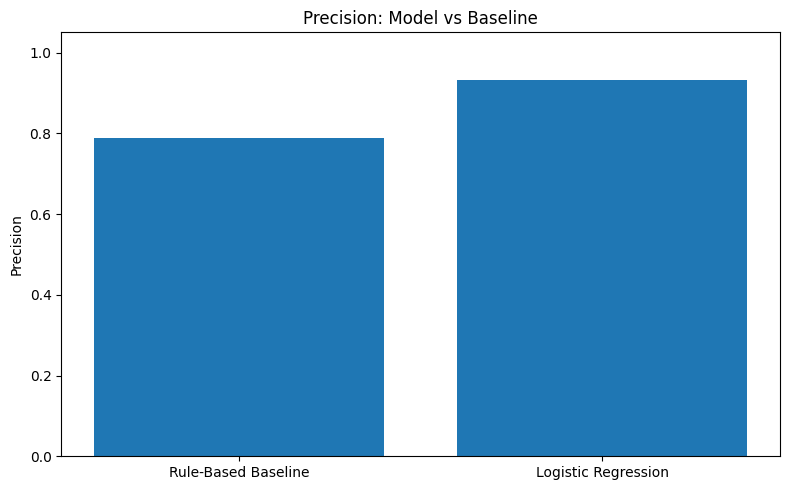

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    results["Method"],
    results["Precision"]
)

plt.title("Precision: Model vs Baseline")
plt.ylabel("Precision")
plt.ylim(0, 1.05)

plt.tight_layout()

plt.savefig(
    "work/figures/model_vs_baseline_precision.png",
    dpi=150
)

plt.show()

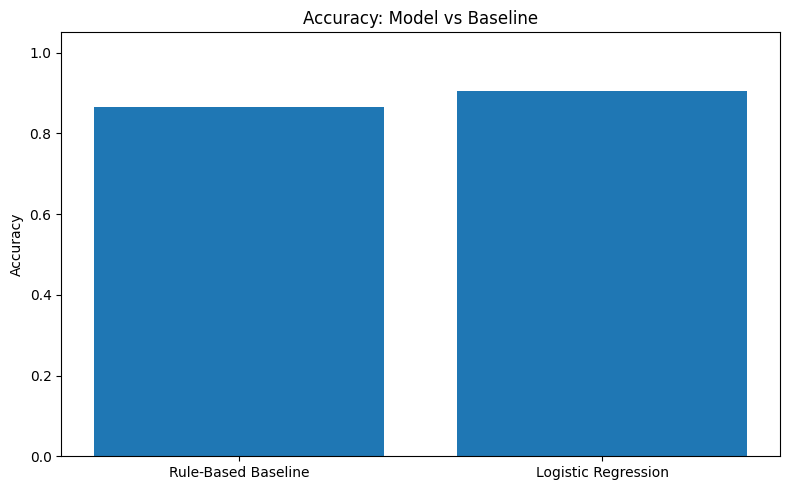

In [56]:
plt.figure(figsize=(8, 5))

plt.bar(
    results["Method"],
    results["Accuracy"]
)

plt.title("Accuracy: Model vs Baseline")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)

plt.tight_layout()

plt.savefig(
    "work/figures/model_vs_baseline_accuracy.png",
    dpi=150
)

plt.show()

In [57]:
recommendation_counts = pd.DataFrame({
    "Action": [
        "Baseline review candidates",
        "Other content"
    ],
    "Count": [
        int(model_clean["baseline_candidate"].sum()),
        int((~model_clean["baseline_candidate"]).sum())
    ]
})

display(recommendation_counts)

,Action,Count
0,Baseline review candidates,87958
1,Other content,74342


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
